In [1]:
import pandas as pd

klienci = pd.read_csv('data/klienci.csv')
klienci.head()

,klientID,plec,wiek,roczny_dochod,wskaznik_wydatkow
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<Axes: xlabel='roczny_dochod', ylabel='wskaznik_wydatkow'>

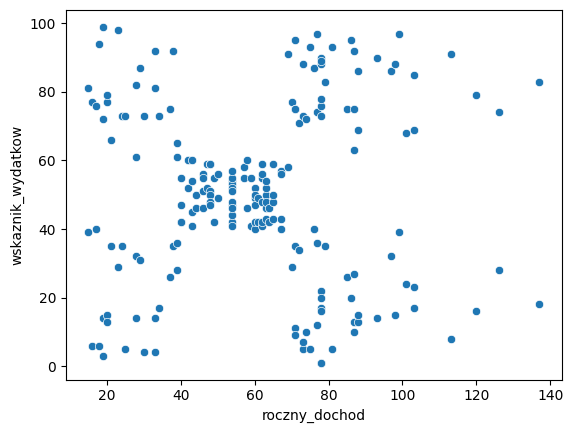

In [2]:
import seaborn as sns

sns.scatterplot(x = klienci['roczny_dochod'], y = klienci['wskaznik_wydatkow'])

# Standaryzacja

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x = klienci[['roczny_dochod', 'wskaznik_wydatkow']]
z = scaler.fit_transform(x)
z

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

# Metoda k-średnich

grupa_kmeans
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

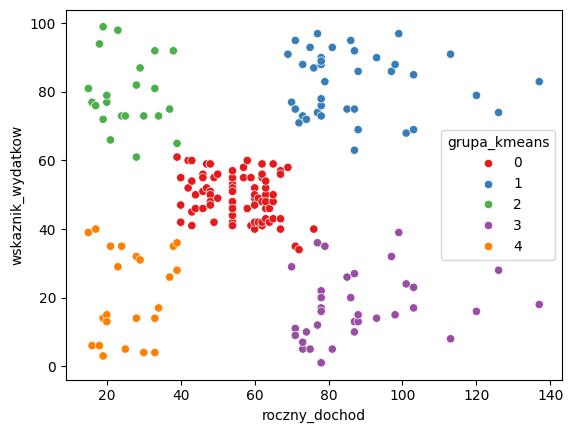

In [13]:
from sklearn.cluster import KMeans

grupy_kmeans = KMeans(n_clusters=5, random_state=42)
clusters_kmeans = grupy_kmeans.fit_predict(z)
clusters_kmeans

klienci['grupa_kmeans'] = clusters_kmeans

sns.scatterplot(x = klienci['roczny_dochod'], y = klienci['wskaznik_wydatkow'], hue=klienci['grupa_kmeans'], palette='Set1')

klienci['grupa_kmeans'].value_counts()

## Wybór liczby grup

In [14]:
from sklearn.metrics import calinski_harabasz_score

inertia = []
ch_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(z)
    inertia.append(kmeans.inertia_) # suma kwadratów odległości punktów do najbliższego centroidu
    ch_scores.append(calinski_harabasz_score(z, clusters)) 

print(inertia)
print(ch_scores)

[273.6688866264201, 157.70400815035944, 109.22822707921347, 65.56840815571681, 60.13287487193421, 49.66824483736797, 37.319122878338824, 32.49508119910091, 30.059322694042205]
[91.40081927586573, 151.3351212635948, 173.9210611775394, 248.64932001536357, 219.29509412369103, 226.88550457064687, 266.5608829108479, 270.01563352345875, 259.8148608542566]


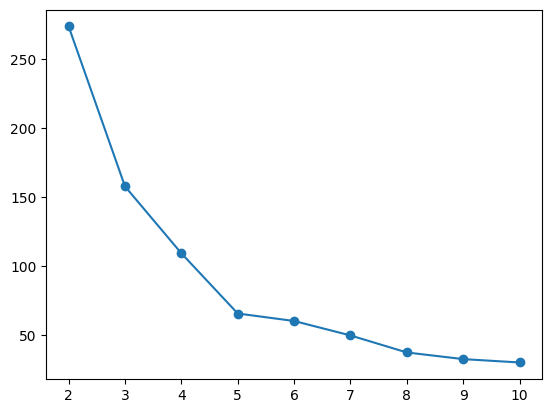

In [15]:
import matplotlib.pyplot as plt

plt.plot(range(2,11), inertia, marker='o')

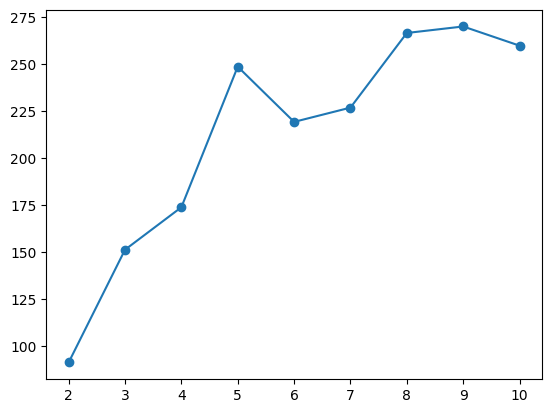

In [16]:
plt.plot(range(2,11), ch_scores, marker='o')

## Zadanie

In [17]:
auta = pd.read_csv('data/auta.csv', sep=';')
auta

,nr,marka,model,pojemnosc,przebieg,lata,cena,diesel
0,1,Fiat,Fiat Seicento ...,899,52000,5,9500,0
1,2,Volkswagen,Volkswagen Corrado ...,2000,188000,12,15900,0
2,4,Ford,Ford Focus Combi ...,1800,125000,5,27900,1
3,5,Opel,Opel Vectra ...,1800,148000,9,16600,0
4,7,Citroen,Citroen Xsara II ...,1400,70000,5,20000,0
5,8,Toyota,Toyota Avensis ...,1600,105000,6,27500,0
6,9,BMW,BMW 320 ...,2000,164000,11,15600,0
7,10,Peugeot,Peugeot 206 ...,1124,72000,6,16000,0
8,11,Volkswagen,Volkswagen Golf IV ...,1400,52000,3,26500,0
9,12,Audi,Audi A3 ...,1600,108000,5,34000,0


Wysoka korelacja (powyżej > 0,9) może sugerować redundancję pomiędzy cechami.

In [18]:
auta[['pojemnosc', 'przebieg', 'lata', 'cena']].corr()

,pojemnosc,przebieg,lata,cena
pojemnosc,1.000000,0.721918,0.360621,0.351001
przebieg,0.721918,1.000000,0.642138,-0.063452
lata,0.360621,0.642138,1.000000,-0.601429
cena,0.351001,-0.063452,-0.601429,1.000000


Cechy o wysokiej zmienności mogą być bardziej istotne w procesie grupowania.

In [19]:
auta[['pojemnosc', 'przebieg', 'lata', 'cena']].std()/auta[['pojemnosc', 'przebieg', 'lata', 'cena']].mean()

pojemnosc    0.198106
przebieg     0.361838
lata         0.359148
cena         0.400801
dtype: float64

In [20]:
x_auta = auta[['pojemnosc', 'przebieg', 'lata', 'cena']]
scaler_auta = StandardScaler()
z_auta = scaler_auta.fit_transform(x_auta)

In [22]:
from sklearn.metrics import calinski_harabasz_score

inertia_auta = []
ch_scores_auta = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(z_auta)
    inertia_auta.append(kmeans.inertia_) # suma kwadratów odległości punktów do najbliższego centroidu
    ch_scores_auta.append(calinski_harabasz_score(z_auta, clusters)) 

print(inertia_auta)
print(ch_scores_auta)

[76.33600226793622, 43.47420439625041, 32.662973349002435, 29.0234580651086, 27.080910489376453, 23.366685264030465, 18.46113493138729, 16.683666270102332, 14.252062791835058]
[20.303918019203547, 28.191983114475992, 27.242230498584416, 23.01902332112805, 19.378198737487335, 18.657851544066485, 20.343376747323532, 19.182501872922728, 19.50949257217756]


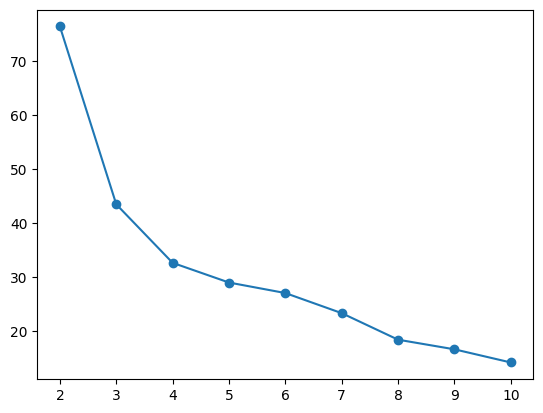

In [23]:
plt.plot(range(2,11), inertia_auta, marker='o')

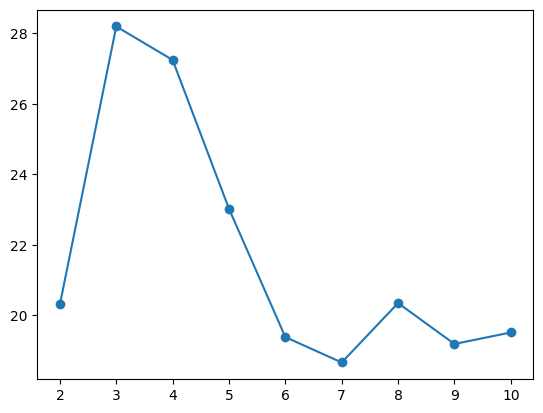

In [24]:
plt.plot(range(2,11), ch_scores_auta, marker='o')

In [25]:
auta["clusters_kmeans"] = KMeans(n_clusters=3, random_state=42).fit_predict(z_auta)
auta[['pojemnosc', 'przebieg', 'lata', 'cena', 'clusters_kmeans']].groupby('clusters_kmeans').mean()

,pojemnosc,przebieg,lata,cena
clusters_kmeans,,,,
0,1226.909091,71327.272727,5.727273,14727.181818
1,1674.100000,160800.000000,9.900000,12940.000000
2,1690.909091,124363.636364,5.363636,25963.636364


# Grupowanie hierarchiczne

grupa_agglomerative
2    85
1    39
0    32
4    23
3    21
Name: count, dtype: int64

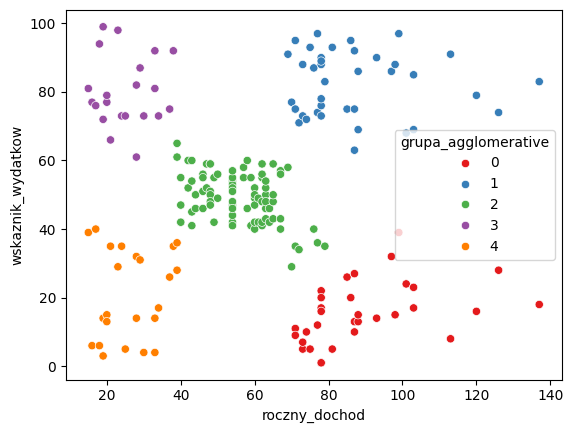

In [28]:
from sklearn.cluster import AgglomerativeClustering

grupy_agglomerative = AgglomerativeClustering(n_clusters=5, linkage='ward')
clusters_agglomerative = grupy_agglomerative.fit_predict(z)
clusters_agglomerative

klienci['grupa_agglomerative'] = clusters_agglomerative
sns.scatterplot(x = klienci['roczny_dochod'], y = klienci['wskaznik_wydatkow'], hue=klienci['grupa_agglomerative'], palette='Set1')
klienci['grupa_agglomerative'].value_counts()

## Dendrogram

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [5.0, 5.0, 20.0, 20.0],
  [75.0, 75.0, 85.0, 85.0],
  [65.0, 65.0, 80.0, 80.0],
  [55.0, 55.0, 72.5, 72.5],
  [45.0, 45.0, 63.75, 63.75],
  [35.0, 35.0, 54.375, 54.375],
  [12.5, 12.5, 44.6875, 44.6875],
  [105.0, 105.0, 115.0, 115.0],
  [95.0, 95.0, 110.0, 110.0],
  [145.0, 145.0, 155.0, 155.0],
  [135.0, 135.0, 150.0, 150.0],
  [165.0, 165.0, 175.0, 175.0],
  [142.5, 142.5, 170.0, 170.0],
  [125.0, 125.0, 156.25, 156.25],
  [185.0, 185.0, 195.0, 195.0],
  [215.0, 215.0, 225.0, 225.0],
  [205.0, 205.0, 220.0, 220.0],
  [190.0, 190.0, 212.5, 212.5],
  [140.625, 140.625, 201.25, 201.25],
  [102.5, 102.5, 170.9375, 170.9375],
  [235.0, 235.0, 245.0, 245.0],
  [255.0, 255.0, 265.0, 265.0],
  [240.0, 240.0, 260.0, 260.0],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [315.0, 315.0, 325.0, 325.0],
  [305.0, 305.0, 320.0, 320.0],
  [282.5, 282.5, 312.5, 312.5],
  [250.0, 250.0, 297.5, 297.5],
  [335.0, 335.0, 345.0, 345.0],
  [355.0

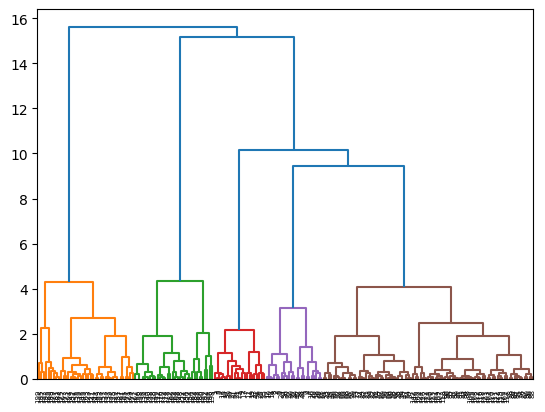

In [33]:
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_matrix = linkage(z, method='ward')

dendrogram(linkage_matrix, color_threshold=5)

## Zadanie

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [35.0, 35.0, 45.0, 45.0],
  [55.0, 55.0, 65.0, 65.0],
  [40.0, 40.0, 60.0, 60.0],
  [20.0, 20.0, 50.0, 50.0],
  [5.0, 5.0, 35.0, 35.0],
  [85.0, 85.0, 95.0, 95.0],
  [75.0, 75.0, 90.0, 90.0],
  [20.0, 20.0, 82.5, 82.5],
  [105.0, 105.0, 115.0, 115.0],
  [135.0, 135.0, 145.0, 145.0],
  [125.0, 125.0, 140.0, 140.0],
  [110.0, 110.0, 132.5, 132.5],
  [155.0, 155.0, 165.0, 165.0],
  [185.0, 185.0, 195.0, 195.0],
  [175.0, 175.0, 190.0, 190.0],
  [160.0, 160.0, 182.5, 182.5],
  [121.25, 121.25, 171.25, 171.25],
  [215.0, 215.0, 225.0, 225.0],
  [205.0, 205.0, 220.0, 220.0],
  [245.0, 245.0, 255.0, 255.0],
  [235.0, 235.0, 250.0, 250.0],
  [275.0, 275.0, 285.0, 285.0],
  [265.0, 265.0, 280.0, 280.0],
  [305.0, 305.0, 315.0, 315.0],
  [295.0, 295.0, 310.0, 310.0],
  [272.5, 272.5, 302.5, 302.5],
  [242.5, 242.5, 287.5, 287.5],
  [212.5, 212.5, 265.0, 265.0],
  [146.25, 146.25, 238.75, 238.75],
  [51.25, 51.25, 192.5, 192.5]],
 'dcoord': [[0.0,
   np.flo

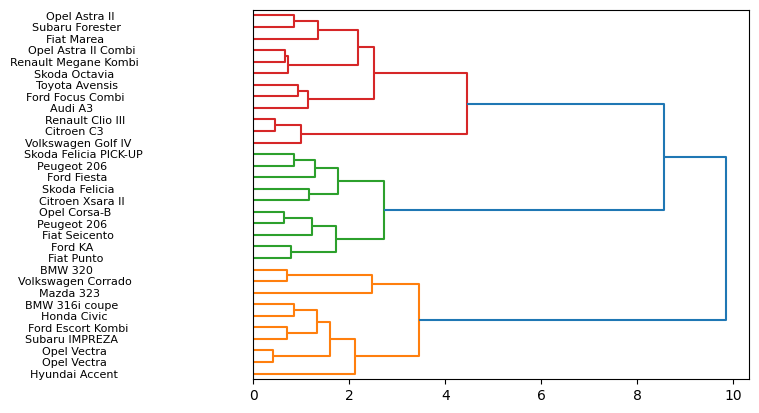

In [37]:
auta_linked = linkage(z_auta, method='ward')

dendrogram(auta_linked, color_threshold=5, orientation='right', labels=auta['model'].values)

# Redukcja wymiarowości

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
z_pca = pca.fit_transform(z_auta)

In [40]:
pca.explained_variance_ratio_

array([0.54784079, 0.3751816 ])

In [41]:
sum(pca.explained_variance_ratio_)

np.float64(0.9230223931128255)

<Axes: >

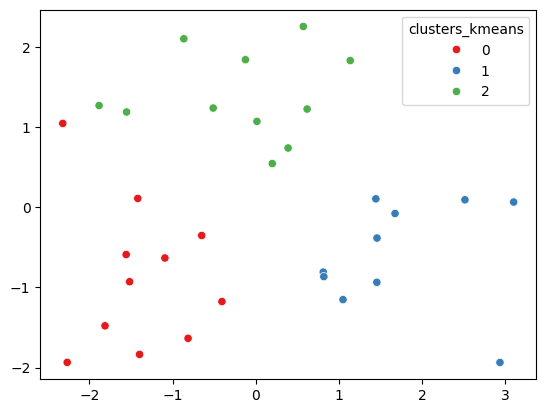

In [43]:
sns.scatterplot(x = z_pca[:,0], y = z_pca[:,1], hue=auta['clusters_kmeans'], palette='Set1')

In [ ]:
! pip install umap-learn

d:\CDV\mad_gr1\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: >

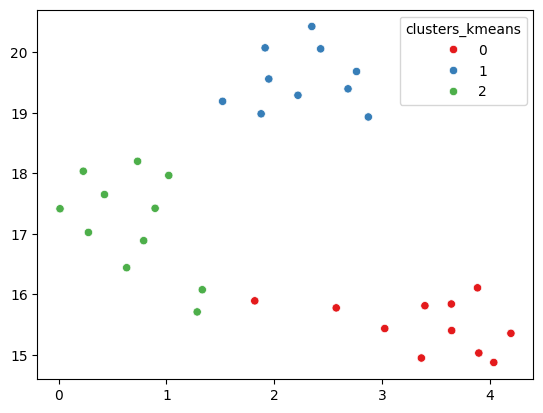

In [48]:
from umap import UMAP

umap = UMAP(n_components=2, random_state=44)
z_umap = umap.fit_transform(z_auta)

sns.scatterplot(x = z_umap[:,0], y = z_umap[:,1], hue=auta['clusters_kmeans'], palette='Set1')